In [9]:
# MNIST dataset으로 CNN 실습
import tensorflow as tf
print(tf.__version__)   # 2.20.0
import numpy as np
import matplotlib.pyplot as plt

# 1) 데이터 준비
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print(x_train[0])
print(x_test.shape)

# 채널(channel) 추가 (흑백인 경우 1)
x_train = x_train.reshape((-1, 28, 28, 1)).astype('float') / 255.0   # 정규화
x_test = x_test.reshape((-1, 28, 28, 1)).astype('float') / 255.0
print(x_train.shape)   # (60000, 28, 28, 1)

2.20.0
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253

In [14]:
# 2) 모델 정의
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(filters=16, kernel_size=(3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2,2)),     # pool_size= 2
    tf.keras.layers.Dropout(rate=0.2),

    tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2,2)),
    tf.keras.layers.Dropout(rate=0.2),

    tf.keras.layers.Flatten(),  # FCLayer(Fully Connected Layer)  1차원으로 구조 변경


    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dropout(rate=0.3),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=10, activation='softmax')
])

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,626 (420.41 KB)

 Trainable params: 107,626 (420.41 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

es = tf.keras.callbacks.EarlyStopping(monitor= 'val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    x_train, y_train, epochs=100, batch_size=128, validation_split=0.1, callbacks=[es], verbose=1
)



Epoch 1/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.8012 - loss: 0.6166 - val_accuracy: 0.9708 - val_loss: 0.1040
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9368 - loss: 0.2162 - val_accuracy: 0.9817 - val_loss: 0.0650
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9542 - loss: 0.1591 - val_accuracy: 0.9842 - val_loss: 0.0614
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9629 - loss: 0.1326 - val_accuracy: 0.9873 - val_loss: 0.0464
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9675 - loss: 0.1153 - val_accuracy: 0.9882 - val_loss: 0.0439
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9715 - loss: 0.1009 - val_accuracy: 0.9885 - val_loss: 0.0425
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9731 - loss: 0.0928 - val_accuracy: 0.9885 - val_loss: 0.0417
Epoch 8/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9745 - loss: 0.0886 - val_ac

In [17]:
# 모델 평가 : 아래 둘의 평가 점수의 차이가 크면 과적합 의심
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
print(f'Train Loss: {train_loss:.4f}, train Accyuracy: {train_acc:.4f}')
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Loss: {test_loss:.4f}, Test Accyuracy: {test_acc:.4f}')


Train Loss: 0.0264, train Accyuracy: 0.9925
Test Loss: 0.0316, Test Accyuracy: 0.9901


In [18]:
# 모델 저장 및 재로딩
SAVE_PATH = 'cnn1model.keras'
model.save(SAVE_PATH)
print(f'모델 저장 {SAVE_PATH}')

모델 저장 cnn1model.keras


In [19]:
loaded_model = tf.keras.models.load_model(SAVE_PATH)
train_loss, train_acc = loaded_model.evaluate(x_train, y_train, verbose=0)
print(f'[Reloaded]Test Loss: {test_loss:.4f}, test Accyuracy: {test_acc:.4f}')


[Reloaded]Test Loss: 0.0316, test Accyuracy: 0.9901


In [23]:
# 분류 예측 (편의상 기본 자료 사용)
idx = 0
x_one = x_test[idx:idx + 1]
y_true = int(y_test[idx])
print(x_one)
print(y_true) # 7

probs = loaded_model.predict(x_one, verbose=0)[0]
print('probs : ', probs)
y_pred = int(np.argmax(probs))
print(f'실제값:{y_true}, 예측값:{y_pred}')

[[[[0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]]

  [[0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]]

  [[0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [

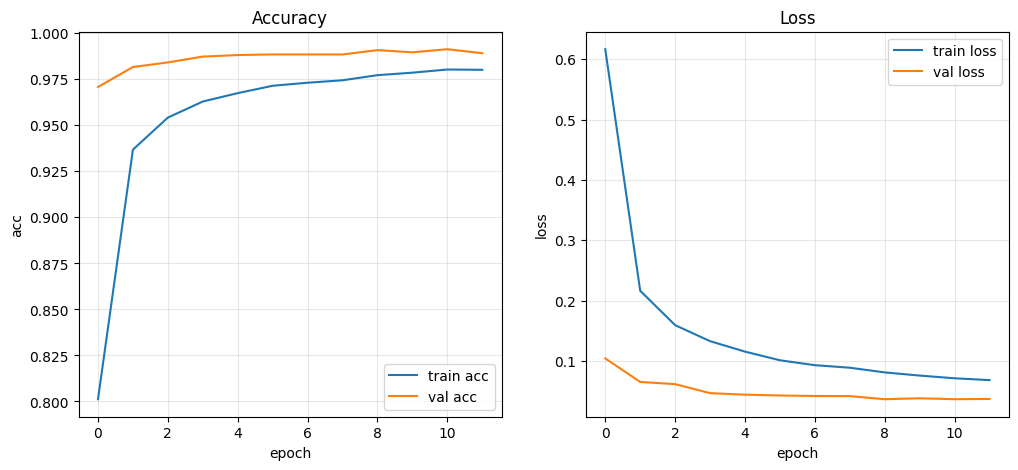

In [27]:
# 시각화
# 학습 곡선 (정화도/손실)
# %matplotlib inline  # %매직명령어 중 matplotlib의 show()처리

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy')
plt.xlabel('epoch')
plt.ylabel('acc')
plt.legend()
plt.grid('True', alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid('True', alpha=0.3)

plt.show()






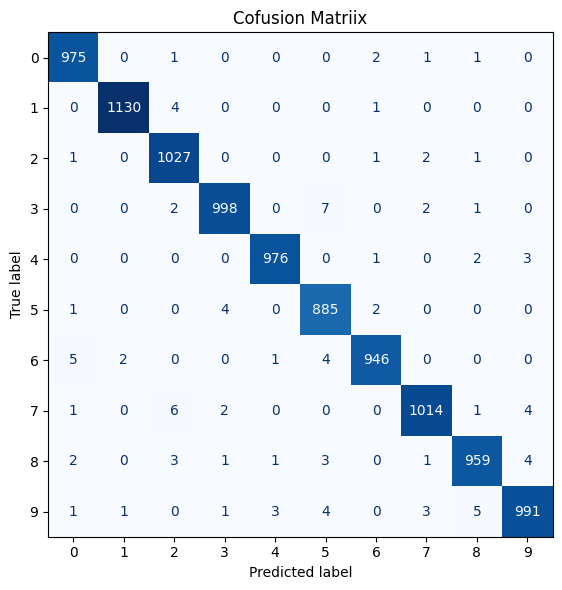

In [28]:
from IPython.core.pylabtools import figsize
# 혼동행렬로 출력
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred_all = np.argmax(loaded_model.predict(x_test, verbose=0),axis=1)
cm = confusion_matrix(y_test, y_pred_all, labels=list(range(10)))
# print(cm)

classes = [str(i) for i in range(10)]
disp = ConfusionMatrixDisplay(cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
plt.title('Cofusion Matriix')
plt.tight_layout()
plt.show()